In [2]:
library(Seurat)
#library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)
library(tidyverse)
library(ggpubr)
library(RColorBrewer)

In [7]:
R.home()

[1] "/disk1/pengweixing/software/miniforge4/envs/py310/lib/R"

In [ ]:
library(monocle)

In [13]:
#devtools::load_all("/disk1/pengweixing/software/monocle")

In [ ]:
library(tidyverse)
library(magrittr)
library(org.Hs.eg.db)

In [5]:
GCA_epi <- readRDS('GCA_epi.Rds')

In [11]:
lownames <- readRDS("../06.differential/lownames.rds")
highnames <- readRDS("../06.differential/highnames.rds")

In [12]:
GCA_epi@meta.data  %>% mutate(group = ifelse(sample %in% highnames,'high','low')) -> GCA_epi@meta.data

In [13]:
aneuploidnames <- readRDS('/disk1/pengweixing/esophageal/21.singlecell/08.infercnv/infercnv_tumor/aneuploidnames.Rds')

In [14]:
GCA_epi@meta.data  %>% rownames()  -> GCA_epi@meta.data$bc

In [15]:
GCA_epi@meta.data  %>% mutate(ploidy = ifelse(bc %in% aneuploidnames,'aneuploid','dipoid'))  %>% 
    dplyr::select(!c(Maincelltype,RNA_snn_res.1.2,seurat_clusters,subcelltype,temp,bc)) -> GCA_epi@meta.data

In [16]:
#saveRDS(GCA_epi,file = "GCA_epi.Rds")

In [17]:
head(GCA_epi@meta.data,n=3)

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,celltype,ploidy,RNA_snn_res.0.5,group
,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>
AAACGAAGTTACTCAG-1-SC005,SeuratProject,6821,2750,SC005,7.257000,Epi_tumor,aneuploid,4,low
AAAGAACGTAAGGAGA-1-SC005,SeuratProject,3441,1066,SC005,2.906132,Epi_tumor,dipoid,10,low
AAAGAACGTGGCGCTT-1-SC005,SeuratProject,1888,972,SC005,12.235169,Epi_tumor,dipoid,1,low


In [18]:
GCA_epi@meta.data %>% dplyr::count(group,celltype)

group,celltype,n
<chr>,<chr>,<int>
high,Epi_normal,55
high,Epi_tumor,3375
low,Epi_normal,1520
low,Epi_tumor,1756


In [58]:
Idents(GCA_epi) <- 'celltype'

In [59]:
deg <- FindAllMarkers(GCA_epi, only.pos = TRUE)

Calculating cluster Epi_tumor

Calculating cluster Epi_normal



In [64]:
deg %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1&p_val_adj<0.05) -> deg2

In [193]:
rbind(deg2[deg2$cluster == 'Epi_normal',],deg2[deg2$cluster == 'Epi_tumor',]) -> deg3

In [65]:
## ordering by marker gene per cluster
sel.gene <- unique(deg2$gene)

### convert it to CellDataSet

In [ ]:
cds <- as.CellDataSet(GCA_epi)

In [ ]:
cds <- estimateSizeFactors(cds)
cds <- estimateDispersions(cds)

In [556]:
cds <- detectGenes(cds, min_expr = 0.1)
expressed_genes <- row.names(subset(fData(cds), num_cells_expressed >= 10))

In [173]:
diff_test_res <- differentialGeneTest(cds[expressed_genes,],cores = 50,
              fullModelFormulaStr = "~celltype")

In [174]:
ordering_genes <- row.names(subset(diff_test_res, qval < 0.01))

### do monocle trajectory

In [557]:
cds <- setOrderingFilter(cds, deg3$gene)

In [6]:
cds

CellDataSet (storageMode: environment)
assayData: 36601 features, 6706 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: AAACGAAGTTACTCAG-1-SC005 AAAGAACGTAAGGAGA-1-SC005 ...
    TTTGTTGTCACATCAG-1-SC032 (6706 total)
  varLabels: orig.ident nCount_RNA ... State (13 total)
  varMetadata: labelDescription
featureData
  featureNames: MIR1302-2HG FAM138A ... AC007325.2 (36601 total)
  fvarLabels: vf_vst_counts.SC005_mean vf_vst_counts.SC005_variance ...
    use_for_ordering (47 total)
  fvarMetadata: labelDescription
experimentData: use 'experimentData(object)'
Annotation:  

In [5]:
## dimension reduciton
cds <- reduceDimension(cds, method = 'DDRTree')

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



In [559]:
## ordering cells
cds <- orderCells(cds)

Warning message in dfs(graph = graph, root = root, mode = mode, unreachable = unreachable, :
“Argument `neimode' is deprecated; use `mode' instead”
Warning message in dfs(graph = graph, root = root, mode = mode, unreachable = unreachable, :
“Argument `neimode' is deprecated; use `mode' instead”


In [560]:
GM_state <- function(cds){
  if (length(unique(pData(cds)$State)) > 1){
    T0_counts <- table(pData(cds)$State, pData(cds)$celltype)[,"Epi_normal"]
    return(as.numeric(names(T0_counts)[which(T0_counts == max(T0_counts))]))
  } else {
    return (1)
  }
}

In [ ]:
cds <- orderCells(cds, root_state =  GM_state(cds))

In [562]:
saveRDS(cds,"Epi_cds.Rds")

In [19]:
options(repr.plot.height=6,repr.plot.width=5)
p_all_trajectory <- plot_cell_trajectory(cds, color_by = "celltype")+
                    scale_color_manual(values = c('#d95967','#9E0142'))

Warning message:
“`select_()` was deprecated in dplyr 0.7.0.
ℹ Please use `select()` instead.
ℹ The deprecated feature was likely used in the monocle package.
  Please report the issue to the authors.”


In [ ]:
saveRDS(p_all_trajectory,file = "c1.rds")

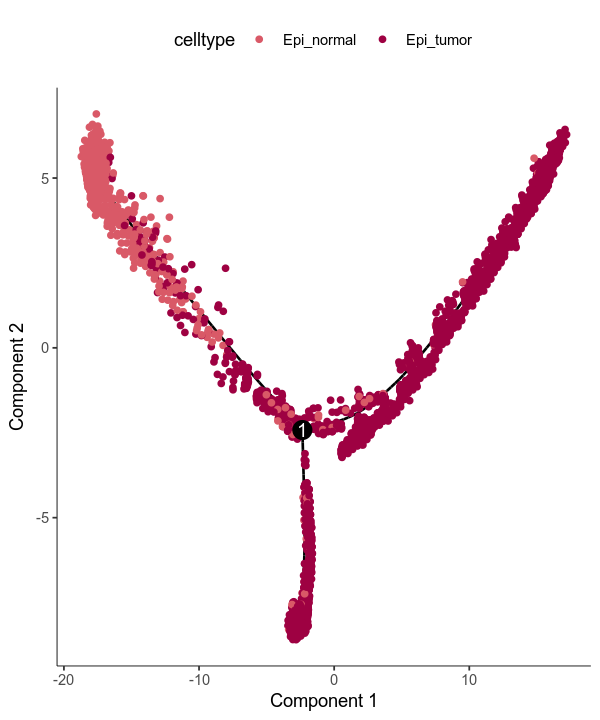

In [20]:
p_all_trajectory

In [ ]:
options(repr.plot.height=6,repr.plot.width=5)
plot_cell_trajectory(cds, color_by = "group")
                 #   scale_color_manual(values = c('#d95967','#9E0142'))

In [17]:
ggsave(filename = "Cell_trajectory_color_bycelltype.pdf",plot =ggrastr::rasterize(p_all_trajectory,dpi=300),height = 6,width = 5 )

In [194]:
options(repr.plot.height=6,repr.plot.width=8)
p2_state_color_split = plot_cell_trajectory(cds, color_by = "State") + facet_wrap(~group, ncol = 2) 
p2_state_color_all = plot_cell_trajectory(cds, color_by = "State") 

In [6]:
cds$Pseudotime

CellDataSet (storageMode: environment)
assayData: 36601 features, 6706 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: AAACGAAGTTACTCAG-1-SC005 AAAGAACGTAAGGAGA-1-SC005 ...
    TTTGTTGTCACATCAG-1-SC032 (6706 total)
  varLabels: orig.ident nCount_RNA ... State (13 total)
  varMetadata: labelDescription
featureData
  featureNames: MIR1302-2HG FAM138A ... AC007325.2 (36601 total)
  fvarLabels: vf_vst_counts.SC005_mean vf_vst_counts.SC005_variance ...
    use_for_ordering (47 total)
  fvarMetadata: labelDescription
experimentData: use 'experimentData(object)'
Annotation:  

In [41]:
p2_psedutime_color_all = plot_cell_trajectory(cds, color_by = "Pseudotime") 

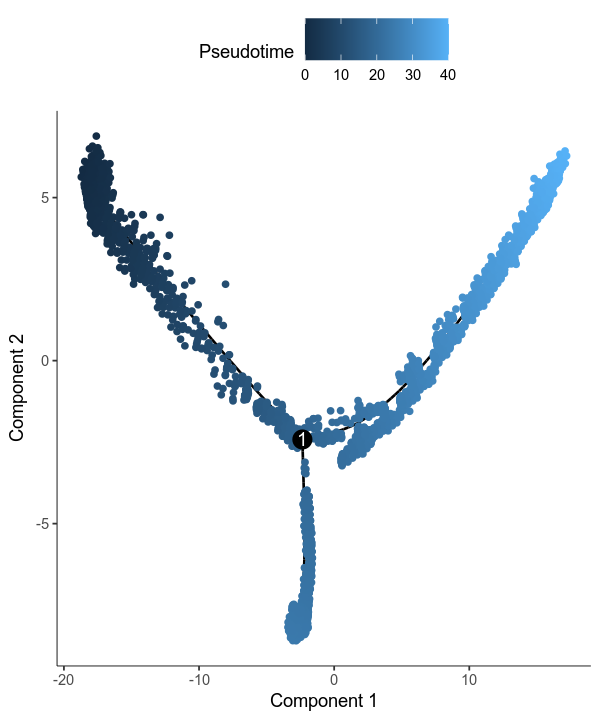

In [42]:
p2_psedutime_color_all

In [9]:
ggsave(filename = "Cell_trajectory_color_Psedotime.pdf",plot =p2_psedutime_color_all,height = 5,width = 4 )

In [4]:
library(ggrastr)

In [22]:
options(repr.plot.height=5,repr.plot.width=4)
p2_state_color_all <- rasterize(p2_state_color_all,dpi=300)

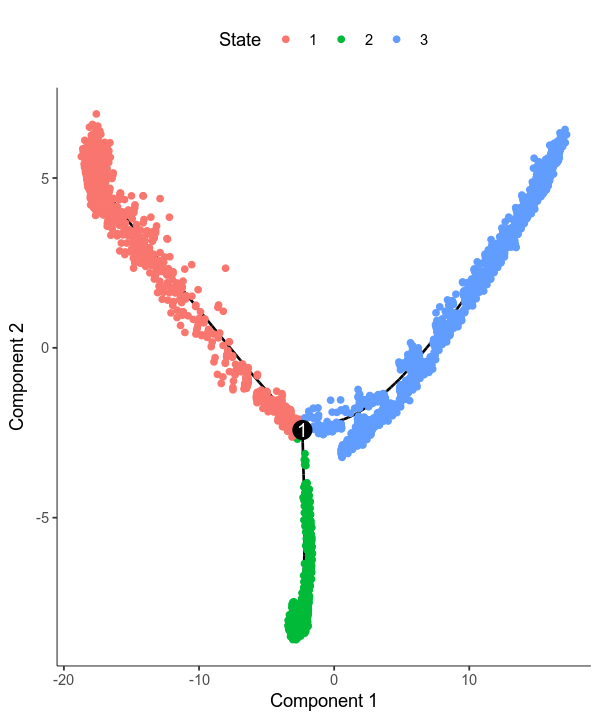

In [43]:
p2_state_color_all

In [44]:
saveRDS(list(left =p2_psedutime_color_all,right = p2_state_color_all),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig26a.Rds")

In [7]:
options(repr.plot.height=6,repr.plot.width=8)
p2_state_color_split <- rasterize(p2_state_color_split,dpi=300)

In [24]:
ggsave(filename = "Cell_trajectory_color_byState.pdf",plot =p2_state_color_all,height = 5,width = 4 )

In [13]:
ggsave(filename = "Cell_trajectory_color_byState_HighLow.pdf",plot =p2_state_color_split,height = 4,width = 6)

In [18]:
options(repr.plot.height=6,repr.plot.width=8)
p3 <- plot_cell_trajectory(cds, color_by = "celltype") + facet_wrap(~group, ncol = 2) + scale_color_manual(values = c('#d95967','#9E0142'))

In [29]:
saveRDS(list(first = p_all_trajectory,
             second = p2_state_color_all,
            third = p4),file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure6c.Rds")

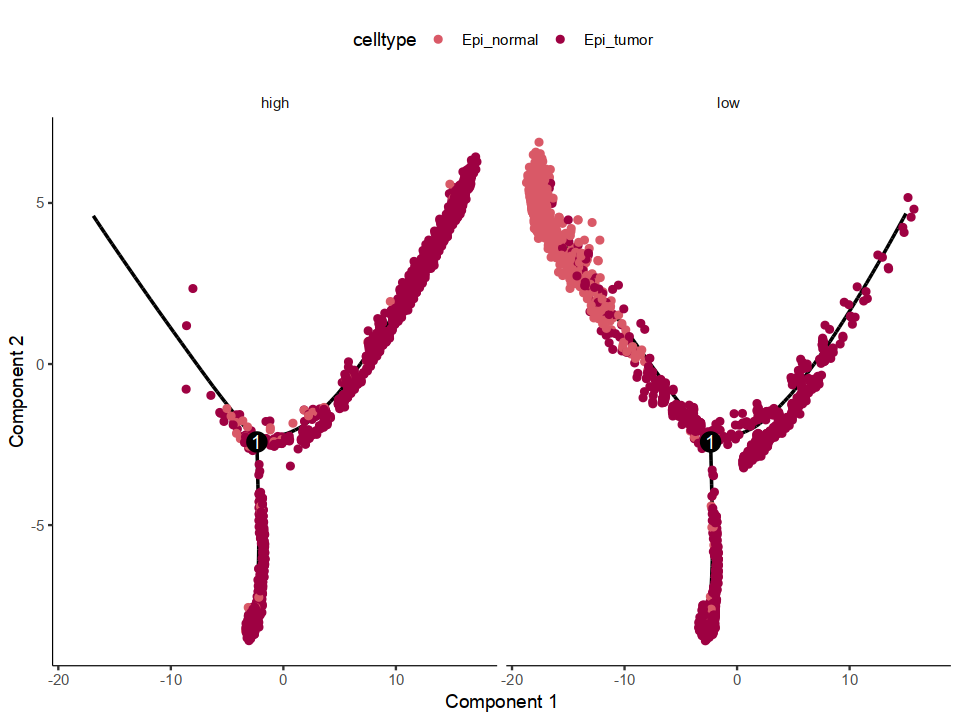

In [19]:
p3

In [21]:
ggsave(filename = "Cell_trajectory_color_byCelltype_HighLow.pdf",plot =ggrastr::rasterize(p3,dpi=300),height = 4,width = 6)

In [207]:
options(repr.plot.height=6,repr.plot.width=8)
p4 <- plot_cell_trajectory(cds, color_by = "ploidy") + facet_wrap(~group, ncol = 2) 

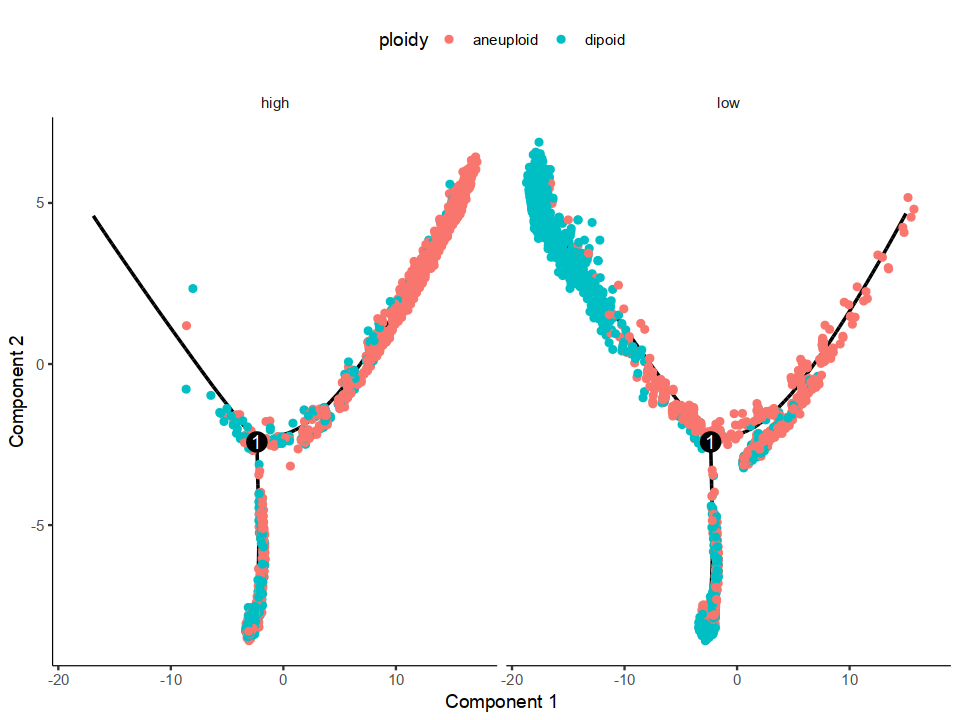

In [208]:
p4

In [16]:
ggsave(filename = "Cell_trajectory_color_byPloidy_HighLow.pdf",plot =rasterize(p4,dpi=300),height = 4,width = 6)

In [216]:
options(repr.plot.height=8,repr.plot.width=8)
p5 <- plot_cell_trajectory(cds, color_by = "Pseudotime") +
    facet_wrap(~State+group, nrow = 3)

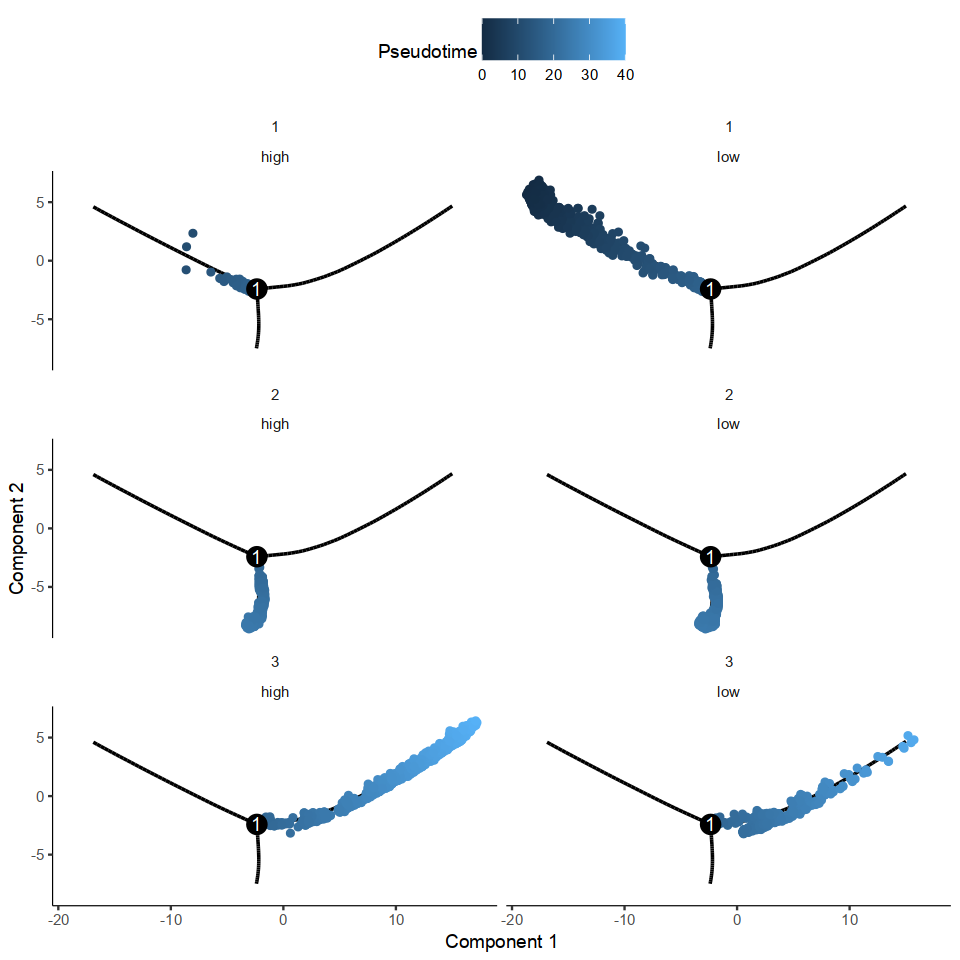

In [217]:
p5

In [220]:
ggsave(filename = "Cell_trajectory_color_byPseuotime_HighLow.pdf",plot =p5,height = 6,width = 4)

In [ ]:
diff_test_res <- differentialGeneTest(cds,
              fullModelFormulaStr = "~sm.ns(Pseudotime)")

In [44]:
sig_gene_names <- row.names(subset(diff_test_res, qval < 0.01))

In [54]:
length(sig_gene_names)

[1] 13696

In [56]:
plot_pseudotime_heatmap(cds[sig_gene_names,],
                num_clusters = 3,
                cores = 1,
                show_rownames = T)

In [68]:
expressed_genes <-  row.names(subset(fData(cds),
num_cells_expressed >= 10))
filtered <- cds[expressed_genes,]
my_genes <- row.names(subset(fData(filtered),
          gene_short_name %in% c("ERBB3","NRG3",'NRG4','EGFR','MTOR','CXCL3','CXCL5','CXCL8')))
cds_subset <- filtered[my_genes,]

In [70]:
options(repr.plot.height=10,repr.plot.width=8)
p5 <- plot_genes_in_pseudotime(cds_subset, color_by = "State")

In [45]:
saveRDS(cds_subset,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig26b.Rds")

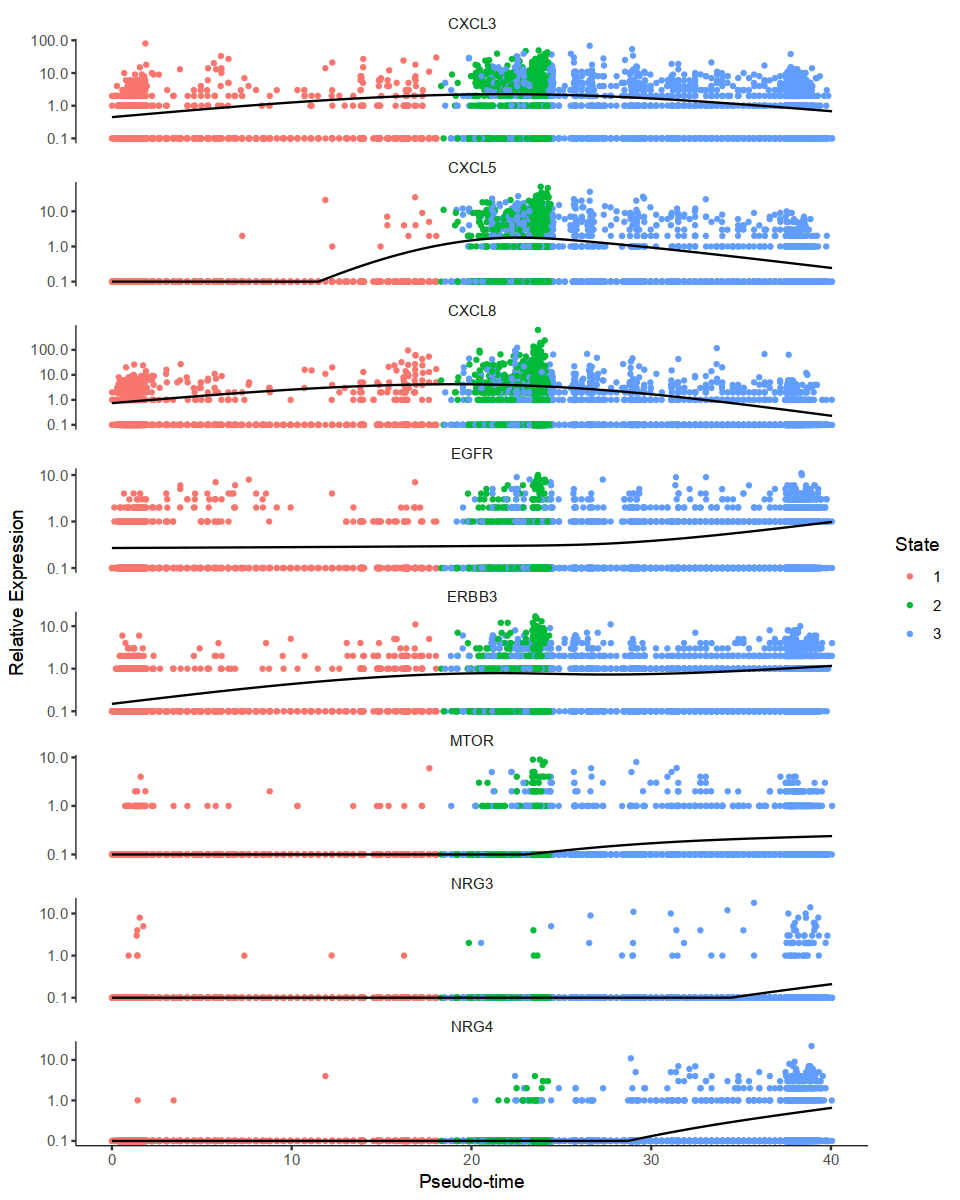

In [71]:
p5

In [74]:
ggsave(filename = "Cell_trajectory_color_byPseuotime_HighLow.pdf",plot =ggrastr::rasterize(p5,dpi=300),
       height = 10,width = 8)

In [303]:
metadata <- data.frame(state= cds$State,group = cds$group,celltype = cds$celltype,ploidy = cds$ploidy) 
metadata$celltype <- factor(metadata$celltype,levels = c('Epi_normal','Epi_tumor'))
metadata  %>% count(state,celltype)  %>% complete(state, celltype, fill = list(n = 0)) %>% group_by(state)  %>% 
    reframe(pct = n/sum(n),celltype = celltype,state = state)  %>% mutate(pct = 100*pct) -> metadata_celltype_state

### Check the Tumor and normal cells in three states

In [245]:
options(repr.plot.height=6,repr.plot.width=6)
p6 <- ggplot(data = metadata_celltype_state,aes(x=state,y=pct,fill = celltype)) +geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1))+
    scale_fill_manual(values = c('#D53E4F','#9E0142'))+
    geom_text(aes(label = round(pct,2)),position = position_stack(vjust = 0.5))

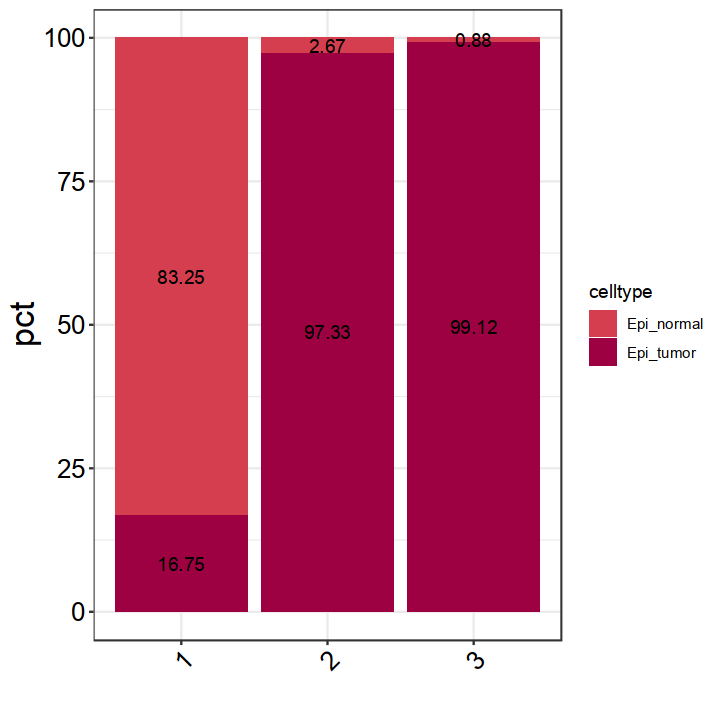

In [246]:
p6

In [247]:
ggsave(filename = "Cell_Bar_StatesByCelltype.pdf",plot = p6,width = 4,height = 6)

In [403]:
metadata  %>% filter(celltype=='Epi_tumor') %>% count(state,group)  %>%
    complete(state, group, fill = list(n = 0)) %>% group_by(state)  -> temp_tumor

In [404]:
metadata  %>% filter(celltype=='Epi_normal') %>% count(state,group)  %>%
    complete(state, group, fill = list(n = 0)) %>% group_by(state)  -> temp_normal

In [ ]:
metadata  %>% filter(state==2|state==3) %>% count(state,group)  %>% complete(state, group, fill = list(n = 0)) %>% group_by(group)  %>% 
    reframe(pct = n/sum(n),group = group,state = state)  %>% mutate(pct = pct) -> metadata_group_state

In [23]:
temp_tumor  %>% group_by(group)  %>% reframe(state = state,pct = n/sum(n),group = group) -> temp_tumor_pct

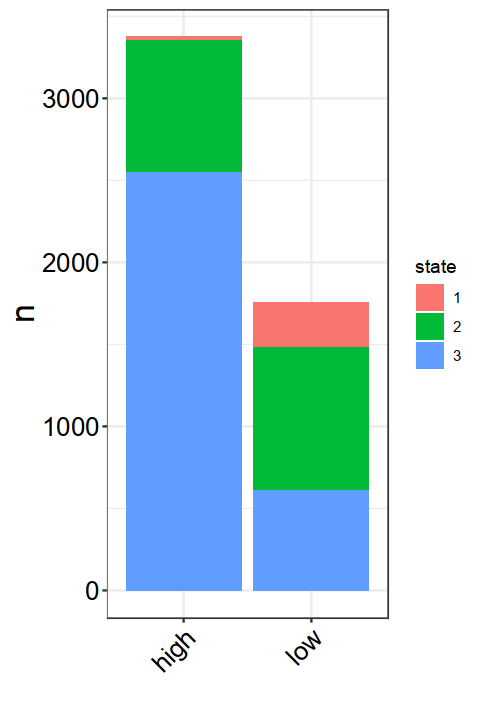

In [33]:
options(repr.plot.height=6,repr.plot.width=4)
ggplot(data = temp_tumor) + geom_bar(aes(x=group,y=n,fill = state),stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1))

In [31]:
library(rcompanion)

### Only for Epi_tumor, check the proportion of states in High and Low

In [34]:
metadata  %>% filter(celltype=='Epi_tumor')  %>% count(group,state)   %>% 
    group_by(group) %>% reframe(pct = n/sum(n), group = group, state = state) ->b

In [35]:
metadata %>% filter(celltype=='Epi_tumor') %>% count(group,state)

group,state,n
<chr>,<fct>,<int>
high,1,24
high,2,805
high,3,2546
low,1,278
low,2,870
low,3,608


In [36]:
matrix(c(24,278,805,870,2546,608),nrow =2) %>% chisq.test()


	Pearson's Chi-squared test

data:  .
X-squared = 995.21, df = 2, p-value < 2.2e-16


In [38]:
cramerV(matrix(c(24,278,805,870,2546,608),nrow =2))

Cramer V 
  0.4404

In [248]:
options(repr.plot.height=6,repr.plot.width=4)
p7 <- ggplot(data = b,aes(x=group,y=pct,fill = state)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))

In [32]:
saveRDS(list(left = metadata_celltype_state,right = b),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure6d.Rds")

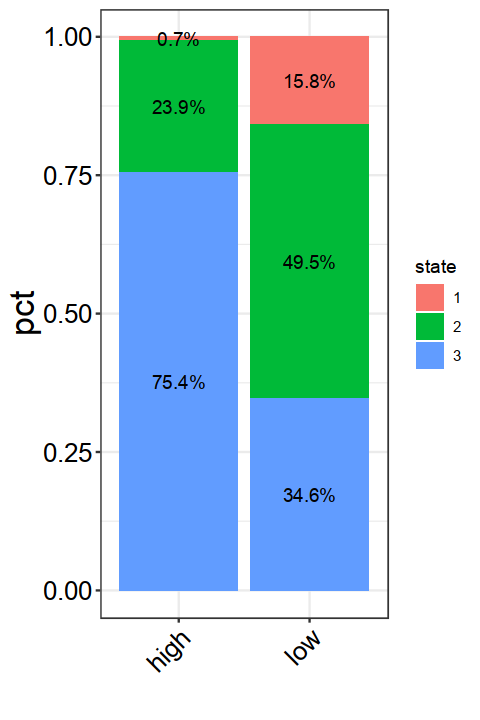

In [249]:
p7

In [258]:
ggsave(filename = "Cell_Bar_GroupByCellState.pdf",plot = p7,width = 4,height = 6)

### Only for Epi_tumor and anueploid, check the proportion of states in High and Low

In [14]:
metadata  %>% filter(celltype=='Epi_tumor'&ploidy=='aneuploid')  %>% count(group,state)   %>% 
    group_by(group) %>% reframe(pct = n/sum(n),group = group,state = state) ->b2

In [15]:
metadata  %>% filter(celltype=='Epi_tumor'&ploidy=='aneuploid')  %>% count(group,state) 

group,state,n
<chr>,<fct>,<int>
high,1,12
high,2,309
high,3,2298
low,1,212
low,2,290
low,3,480


In [450]:
matrix(c(12,211,309,290,2298,480),nrow =2)  %>% chisq.test()


	Pearson's Chi-squared test

data:  .
X-squared = 785.2, df = 2, p-value < 2.2e-16


In [454]:
cramerV(matrix(c(12,211,309,290,2298,480),nrow =2))

Cramer V 
   0.467

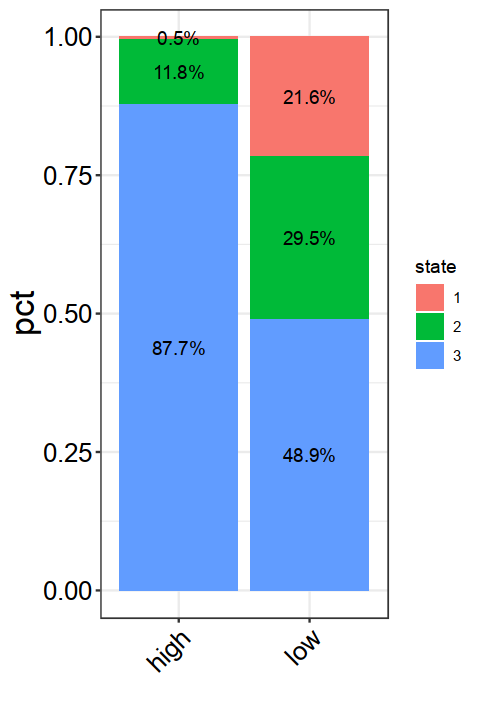

In [379]:
options(repr.plot.height=6,repr.plot.width=4)
ggplot(data = b2,aes(x=group,y=pct,fill = state)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))

### Check the anueploid cell proportions in different states in Tumor cells

In [53]:
metadata  %>% filter(celltype=='Epi_tumor') %>% count(ploidy,state)  %>% group_by(state) %>% reframe(pct = n/sum(n),ploidy = ploidy,n = n,
                                                                   state = state) ->b3

In [254]:
options(repr.plot.height=6,repr.plot.width=4)
p81<- ggplot(data = b3,aes(x=state,y=pct,fill = ploidy)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = scales::percent(pct)),position = position_stack(vjust = 0.5))+geom_hline(yintercept = 0.3)

In [255]:
options(repr.plot.height=6,repr.plot.width=4)
p82 <- ggplot(data = b3,aes(x=state,y=n,fill = ploidy)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = n),position = position_stack(vjust = 0.5))

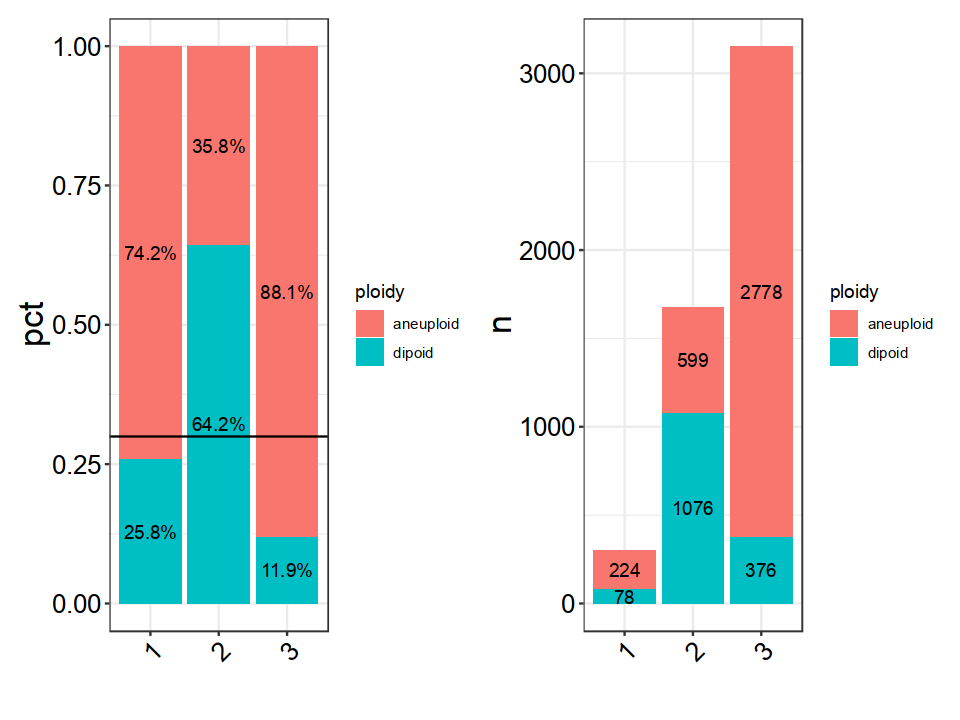

In [256]:
options(repr.plot.height=6,repr.plot.width=8)
p81+p82

In [57]:
cramerV(matrix(c(599,1076,2778,376),nrow=2))

Cramer V 
   0.543

In [257]:
ggsave(filename = "Cell_Bar_CellstateByPloidy.pdf",plot = p81+p82,width =8 ,height = 6)

### compare  high and low anueploid cells in 3

In [58]:
temp_data <- data.frame(group = c('high','high','low','low'),
                        n=c(2619,2298,982,480),
                        states = c('Rest','3','Rest','3'))

In [59]:
temp_data

group,n,states
<chr>,<dbl>,<chr>
high,2619,All
high,2298,3
low,982,All
low,480,3


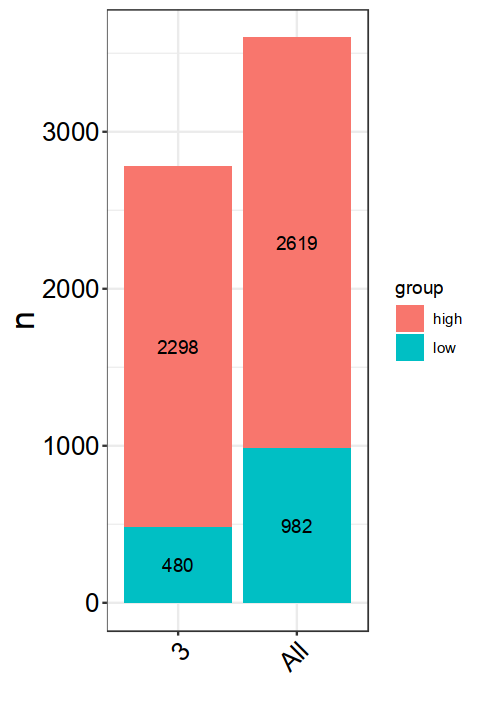

In [60]:
options(repr.plot.height=6,repr.plot.width=4)
ggplot(data = temp_data,aes(x=states,y=n,fill =group)) + geom_bar(stat = 'identity')+
    theme_bw() +xlab('') + theme(axis.text = element_text(color='black',size=15),
                                 axis.title = element_text(size=20),
                                 axis.text.x = element_text(angle=45,hjust=1)) + 
    geom_text(aes(label = n),position = position_stack(vjust = 0.5))

In [62]:
cramerV(matrix(c(2619,2298,982,480),nrow=2))

Cramer V 
  0.1179

### differential genes

In [63]:
diff_test_res <- differentialGeneTest(cds,
              fullModelFormulaStr = "~sm.ns(Pseudotime)")

In [ ]:
diff_test_res$padj <- p.adjust(diff_test_res$pval)

In [ ]:
sig_genes <- subset(diff_test_res, padj < 0.05&num_cells_expressed>4000)

In [ ]:
dim(sig_genes)

In [ ]:
plot_pseudotime_heatmap(cds[rownames(sig_genes),],
                num_clusters = 3,
                cores = 1,
                show_rownames = T)

### branch

In [564]:
BEAM_res <- BEAM(cds, branch_point = 1, cores = 2, progenitor_method = 'duplicate')

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.3 GiB”
Warning message in class(cellData) != "matrix" && isSparseMatrix(cellData) == FALSE:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”


In [565]:
BEAM_res <- BEAM_res[order(BEAM_res$qval),]
BEAM_res <- BEAM_res[,c("gene_short_name", "pval", "qval")]

In [566]:
row.names(subset(BEAM_res,qval < 1e-4)) -> geneorder

- add_annotation_col Additional annotations to show for each column in the heatmap. Must be a dataframe with one row for each cell in the pData table of cds_subset, with matching IDs.

In [572]:
pData(cds)  %>% dplyr::select(group,ploidy,State,Pseudotime) -> colanno

In [33]:
cds_subset <- cds[row.names(subset(BEAM_res,qval < 1e-4)),]

In [9]:
#saveRDS(cds_subset,file = "cds_subset.Rds")

In [34]:
cds_subset

CellDataSet (storageMode: environment)
assayData: 6892 features, 6706 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: AAACGAAGTTACTCAG-1-SC005 AAAGAACGTAAGGAGA-1-SC005 ...
    TTTGTTGTCACATCAG-1-SC032 (6706 total)
  varLabels: orig.ident nCount_RNA ... State (13 total)
  varMetadata: labelDescription
featureData
  featureNames: SH3BGRL3 IFI6 ... IGHV6-1 (6892 total)
  fvarLabels: vf_vst_counts.SC005_mean vf_vst_counts.SC005_variance ...
    use_for_ordering (47 total)
  fvarMetadata: labelDescription
experimentData: use 'experimentData(object)'
Annotation:  

In [36]:
png(file = "Cellfate_heatmap.png",height = 1000,width = 500)
heatmapres <- plot_genes_branched_heatmap(cds_subset,
                                          branch_point = 1,
                                          num_clusters = 4,
                                          cores = 1,
                                          #  add_annotation_col = colanno,
                                          use_gene_short_name = T,
                                          return_heatmap = T,
                                          show_rownames = F)
dev.off()

Warning message in class(cellData) != "matrix" && isSparseMatrix(cellData) == FALSE:
“'length(x) = 2 > 1' in coercion to 'logical(1)'”


png 
  3

In [ ]:
raster::rasterize(heatmapres$ph_res)

In [ ]:
library(ComplexHeatmap)

In [156]:
pdf(file = "Cellfate_heatmap.pdf",height = 8,width = 5)
heatmapres$ph_res
dev.off()

png 
  2

In [38]:
saveRDS(list(heatmap = heatmapres,top = fate1_fate2_pre2),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure6e.Rds")

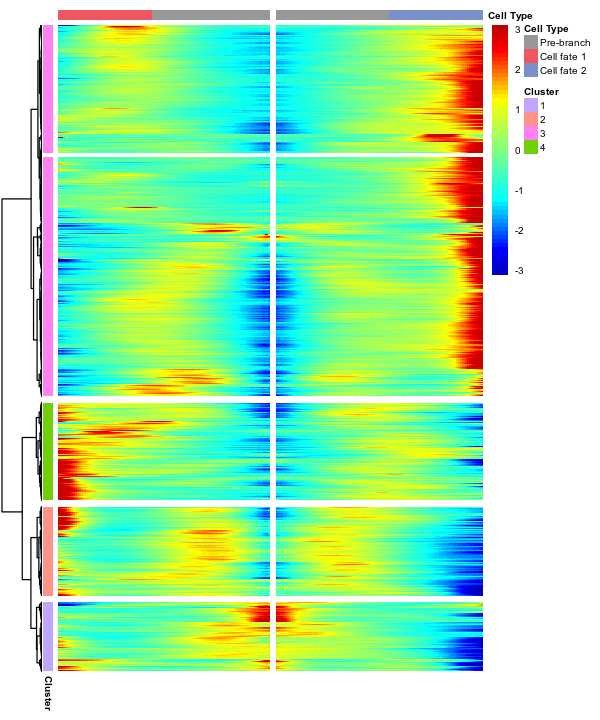

In [33]:
heatmapres$ph_res

In [ ]:
pdf(file = "Cellfate_heatmap.svg",height = 8,width = 5)
heatmapres$ph_res
dev.off()

In [ ]:
pdf(file = "Cellfate_heatmap.svg",height = 8,width = 5)
heatmapres$ph_res
dev.off()

In [150]:
while (!is.null(dev.list()))  dev.off()

In [20]:
pData(heatmapres$new_cds)$Branch  %>% unique()

[1] Y_1 Y_7
Levels: Y_1 Y_7

In [21]:
pData(heatmapres$new_cds)  %>% filter(Branch =='Y_1')   %>% select(original_cell_id) -> Y_1_id
pData(heatmapres$new_cds)  %>% filter(Branch =='Y_7')   %>% select(original_cell_id) -> Y_7_id

In [22]:
Y_1_id$original_cell_id  %>% intersect(Y_7_id$original_cell_id)  %>% length()

[1] 1803

In [29]:
nrow(Y_1_id)-1803 ## cell number in cell fate1 

[1] 1721

In [30]:
nrow(Y_7_id)-1803 ## cell number in cell fate2 

[1] 3182

In [26]:
1803*2  ## cell number in pre-branch 

[1] 3606

In [31]:
1803*2 + 1721 + 3182 == nrow(pData(heatmapres$new_cds) ) ## correct number

[1] TRUE

In [46]:
dim(pData(heatmapres$new_cds))

[1] 8509   15

In [34]:
pData(heatmapres$new_cds) -> heatmap_pdata

In [56]:
rbind(heatmap_pdata[nrow(Y_1_id):1,],heatmap_pdata[(nrow(Y_1_id)+1):nrow(heatmap_pdata),]) -> heatmap_pdata2

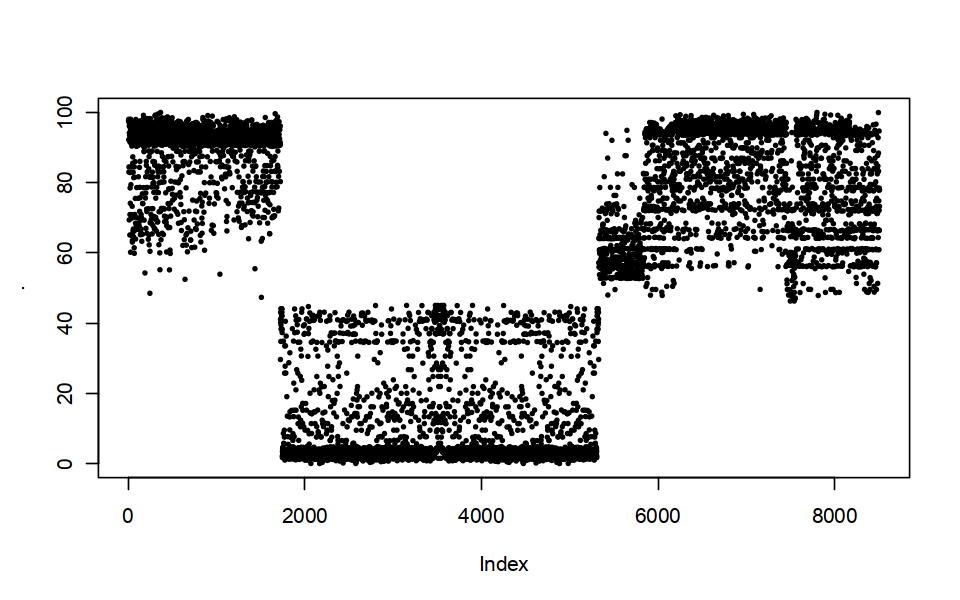

In [59]:
options(repr.plot.height=5,repr.plot.width=8)
heatmap_pdata2$Pseudotime %>% plot(.,xlim=c(0,8509),pch=16,cex=0.5)

In [8]:
heatmapres$BranchP_num

[1] 55

In [13]:
heatmapres$BranchA_num

[1] 45

In [14]:
45*2 + 55 * 2

[1] 200

In [18]:
heatmap_pdata[nrow(Y_1_id):1,] -> newdata1

In [19]:
heatmap_pdata[(nrow(Y_1_id)+1):nrow(heatmap_pdata),] -> newdata2

In [22]:
newdata1[1:1721,] -> cellfate1_data

In [129]:
rbind(newdata1[1722:nrow(newdata1),],newdata2[1:1803,]) -> prebranch_data

In [130]:
newdata2[1804:nrow(newdata2),] -> cellfate2_data

In [131]:
sample(1:1721)  %>% length()

[1] 1721

In [61]:
calculate_frequencies <- function(vec, step_size = 100) {
  n <- length(vec)
  result <- data.frame(Step = integer(), Low = integer(), High = integer())
  
  for (i in seq(1, n, by = step_size)) {
    chunk <- vec[i:min(i + step_size - 1, n)]
    low_count <- sum(chunk == 'low')
    high_count <- sum(chunk == 'high')
    result <- rbind(result, data.frame(Step = i, Low = low_count/(low_count+high_count), 
                                       High = high_count/(low_count+high_count)))
  }
  result 
  return(result)
}

In [62]:
### cellfate1 45 bars
### cellfate2 45 bars
### pre-branch 110 bars
nrow(cellfate1_data)/45
nrow(cellfate2_data)/45
nrow(prebranch_data)/110

[1] 38.24444

[1] 70.71111

[1] 32.79091

In [111]:
fate1_frequency_result <- calculate_frequencies(cellfate1_data$group, 38)

In [112]:
dim(fate1_frequency_result)

[1] 46  3

In [113]:
# Calculate the frequencies
fate2_frequency_result <- calculate_frequencies(cellfate2_data$group, 71)

In [114]:
dim(fate2_frequency_result)

[1] 45  3

In [115]:
pre_frequency_result <- calculate_frequencies(prebranch_data$group, 33)

In [116]:
dim(pre_frequency_result)

[1] 110   3

In [117]:
fate1_fate2_pre <- rbind(fate1_frequency_result,pre_frequency_result,fate2_frequency_result)

In [118]:
fate1_fate2_pre$Step <- seq(1:nrow(fate1_fate2_pre))

In [119]:
fate1_fate2_pre  %>% pivot_longer(!Step)  -> fate1_fate2_pre2

In [120]:
head(fate1_fate2_pre2)

Step,name,value
<int>,<chr>,<dbl>
1,Low,0
1,High,1
2,Low,0
2,High,1
3,Low,0
3,High,1


In [177]:
options(repr.plot.height=4,repr.plot.width=14)
p = ggplot(data = fate1_fate2_pre2,aes(x=Step,y=value,fill=name)) +geom_bar(stat = 'identity',width = 0.7)+
theme_minimal()+theme(panel.grid = element_blank(),axis.ticks.x = element_blank(),axis.text.x = element_blank())+
    ylab("Percentage")+xlab("")+scale_fill_manual(values = c('#CC0000','#2F5688'))

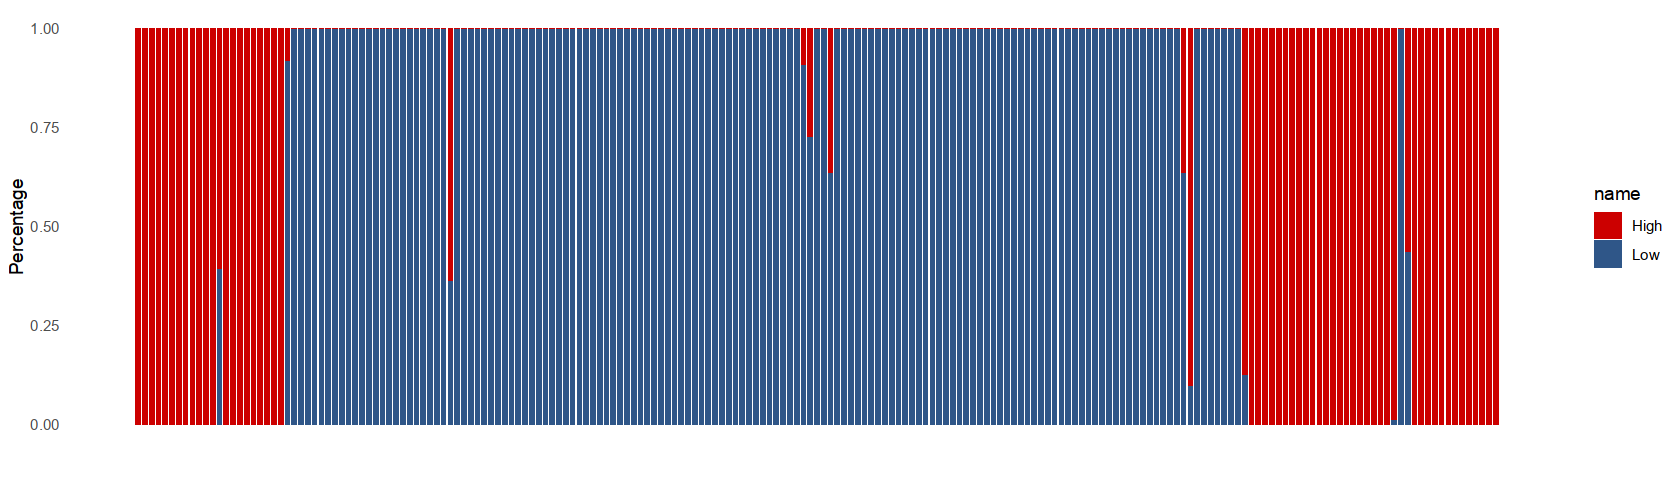

In [178]:
p

In [179]:
ggsave(filename ="Heatmap_barplot_group.pdf",plot = p,height = 2,width = 8)

### for GO annotation

In [65]:
clusters <- cutree(heatmapres$ph_res$tree_row, k=4)[heatmapres$ph_res$tree_row[["order"]]]
annot_row <- data.frame(row.names = names(clusters),
                        cluster = as.factor(clusters))

In [66]:
## 3,4,2,1

In [46]:
openxlsx::write.xlsx(x = list(heatmapgenes = annot_row),rowNames = TRUE,file="Cellfate_heatmap.genes.xlsx")

In [68]:
annot_row  %>% filter(cluster==3)  %>% rownames() -> fate2_gene
annot_row  %>% filter(cluster==4)  %>% rownames() -> fate1_gene

### GO annotation

In [ ]:
library(org.Hs.eg.db)
library(clusterProfiler)
DoGO <- function(data){
    gene_id = data$ENTREZID
    data_go <- enrichGO(gene = 
                         gene_id,
                         OrgDb = org.Hs.eg.db,
                         ont = "BP",
                         pAdjustMethod = "BH",
                         qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05,
                         readable = TRUE)
    return(data_go)
}

In [ ]:
DoKEGG <- function(data){
    gene_id = data$ENTREZID
    data_kegg <- enrichKEGG(gene        = gene_id,
                         organism     = 'hsa',
                          qvalueCutoff = 0.05,
                         pvalueCutoff = 0.05)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [147]:
openxlsx::write.xlsx(x = list(Cellfate1 = fate1_gene,Cellfate2 = fate2_gene),file="Epi_cellfate_GO.xlsx")

In [ ]:
fate1_id = bitr(c(fate1_gene), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

In [ ]:
fate2_id = bitr(c(fate2_gene), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

In [137]:
fate1_GO <- DoGO(fate1_id)
fate2_GO <- DoGO(fate2_id)

In [4]:
openxlsx::write.xlsx(x = list(Cellfate1 = fate1_GO,Cellfate2 = fate2_GO),file="Cellfate_GO.xlsx")

In [ ]:
fate1_kegg <- DoKEGG(fate1_id)
fate2_kegg <- DoKEGG(fate2_id)

In [32]:
openxlsx::write.xlsx(x = list(Cellfate2 = fate2_kegg,Cellfate1 = fate1_kegg),file="Cellfate_KEGG.xlsx")

In [14]:
get_plot <- function(C2_go,C3_go){
    C2_go %>% as.data.frame()  -> C2_temp
    C3_go %>% as.data.frame() -> C3_temp
    C2_temp  %>% select(Description,GeneRatio,p.adjust,Count) %>% 
    mutate(group = "Cellfate1") -> C2_temp2
    C3_temp  %>% select(Description,GeneRatio,p.adjust,Count)  %>% 
        mutate(Description=Description,group = "Cellfate2") -> C3_temp2
    if(nrow(C2_temp2)>10){
        C2_temp2 = C2_temp2[1:10,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }
        
    if(nrow(C3_temp2)>10){
        C3_temp2 = C3_temp2[1:10,]
    }else if(nrow(C3_temp2)>0){
        C3_temp2 = C3_temp2[1:nrow(C3_temp2),]
    }else{
        C3_temp2 = C3_temp
    }
    
    rbind(C2_temp2,C3_temp2) -> C2_C3_comb
    
    
   # C2_C3_comb %>% mutate(GeneRatio2 = sapply(GeneRatio,function(x) eval(parse(text = x))))  -> C2_C3_comb
  #  C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="C2",-GeneRatio2,GeneRatio2)) -> C2_C3_comb
  #  C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))
  #  ceiling(max(abs(C2_C3_comb$GeneRatio2))  * 100) / 100 -> xrange
    
    C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="Cellfate1",'Cellfate1','Cellfate2')) -> C2_C3_comb
    C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))

    p <- ggplot(data = C2_C3_comb) + geom_point(aes(x=GeneRatio2,y = Description,size=Count,color=p.adjust)) + 
        theme(panel.background = element_rect(fill="NA"),
              panel.grid.major.y = element_line(color='gray',linetype='dashed'),
              axis.text = element_text(color = 'black'),
             panel.border = element_rect(fill=NA,color='black'),) + geom_vline(xintercept = 0) +
           # xlim(-xrange,xrange)+
            ylab('')+xlab('') + theme(axis.text.y = element_text(size=11)) +
            scale_colour_gradientn(colors = (colorRampPalette(brewer.pal(9, "RdYlBu"))(100))[0:80])
          #  ggtitle(label =mytype )
    return(p)
}

In [15]:
p_GO <- get_plot(fate1_GO,fate2_GO)

In [16]:
p_kegg <- get_plot(fate1_kegg,fate2_kegg)

In [6]:
p_go_fate1 <- dotplot(fate1_GO, showCategory=20,  label_format = 60) + ggtitle("dotplot for fate1")
p_go_fate2 <- dotplot(fate2_GO, showCategory=20,  label_format = 60) + ggtitle("dotplot for fate2")
p_kegg_fate1 <- dotplot(fate1_kegg, showCategory=20,  label_format = 60) + ggtitle("dotplot for fate1")
p_kegg_fate2 <- dotplot(fate2_kegg, showCategory=20,  label_format = 60) + ggtitle("dotplot for fate2")

In [34]:
saveRDS(list(fate1 = fate1_kegg,
             fate2 = fate2_kegg,
            third = p4),file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure6f.Rds")

In [7]:
library(ggpubr)

In [8]:
p_all <- ggarrange(p_go_fate1,p_go_fate2,p_kegg_fate1,p_kegg_fate2,
          labels = c('GO_Low','GO_High','KEGG_Low','KEGG_High'))

In [ ]:
options(repr.plot.height=12,repr.plot.width=13)
p_all

In [11]:
ggsave(filename = "Epithelial_GO_KEGG.pdf",plot =p_all,width = 13,height = 12)

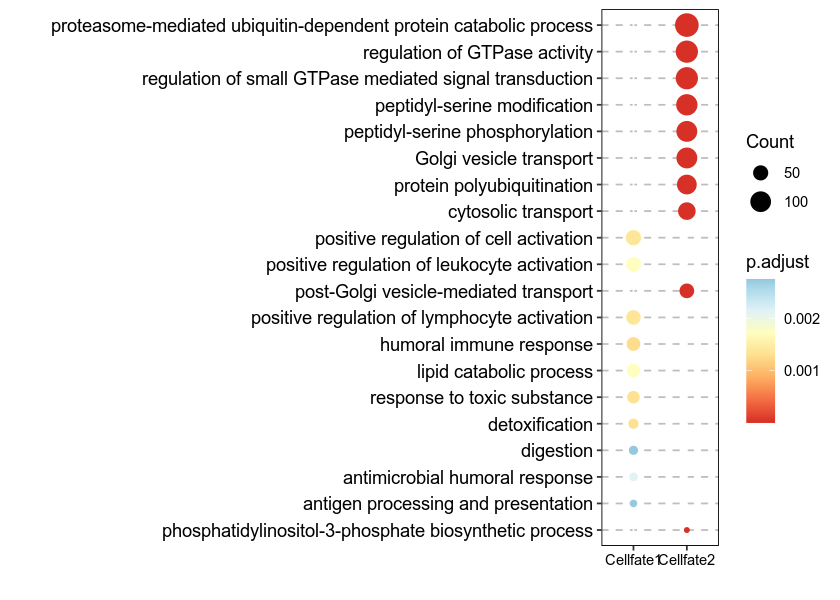

In [16]:
options(repr.plot.height=5,repr.plot.width=7)
p_GO

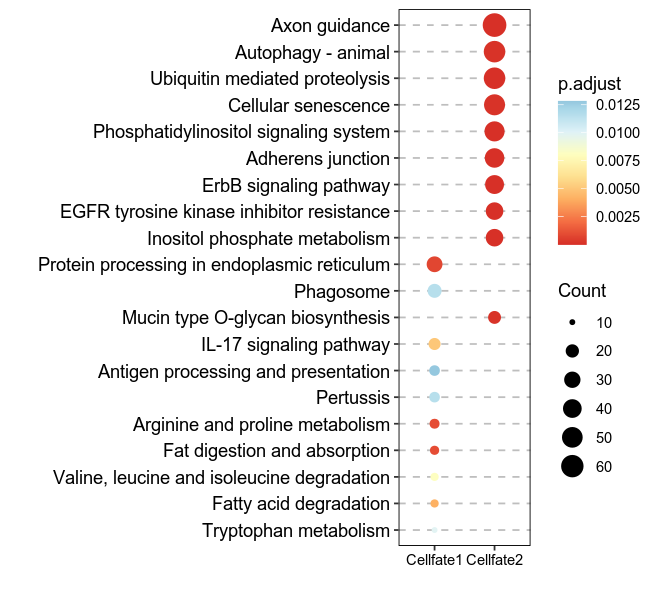

In [17]:
options(repr.plot.height=5,repr.plot.width=5.5)
p_kegg

In [28]:
ggsave(filename ="Cellfate_GOannotation.pdf",plot = p_GO,height = 5,width = 7)

In [27]:
ggsave(filename ="Cellfate_KEGGannotation.pdf",plot = p_kegg,height = 5,width = 5.5)

In [33]:
save.image('monocle_epi.Rds')

In [ ]:
load('monocle_epi.Rds')